<a href="https://colab.research.google.com/github/loopforger/datascience-assignment3/blob/main/GlobalterroristEDAproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = '#0d0d0d'
plt.rcParams['axes.facecolor'] = '#1a1a2e'
plt.rcParams['axes.edgecolor'] = '#444'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['grid.color'] = '#333355'
PALETTE = ['#e94560', '#f5a623', '#4ecca3', '#a78bfa', '#60a5fa', '#f472b6']

## Dataset Loading

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/globalterrorismdb.csv', encoding='latin-1', low_memory=False)
print(df.shape)

(181691, 135)


## Dataset First View

In [ ]:
df.head()

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
3,197001000002,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
4,197001000003,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN


## Rows & Columns Count

In [ ]:
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 181691
Columns : 135


## Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Columns: 135 entries, eventid to related
dtypes: float64(55), int64(22), object(58)
memory usage: 187.1+ MB


## What Did You Know About Your Dataset?

In [ ]:
print("Source   : Global Terrorism Database (GTD) / UNGTA")
print("Period   : 1970 to 2017")
print("Records  : 181,691 terrorist incidents worldwide")
print("Key Cols : iyear, imonth, iday, country_txt, region_txt, attacktype1_txt, targtype1_txt, gname, weaptype1_txt, nkill, nwound, nkillter")
print("Target   : Understanding attack patterns, casualties, hotspots, and perpetrator behavior.")
print("Use Case : Policy making, counter-terrorism strategy, resource allocation for affected regions.")

Source   : Global Terrorism Database (GTD) / UNGTA
Period   : 1970 to 2017
Records  : 181,691 terrorist incidents worldwide
Key Cols : iyear, imonth, iday, country_txt, region_txt, attacktype1_txt, targtype1_txt, gname, weaptype1_txt, nkill, nwound, nkillter
Target   : Understanding attack patterns, casualties, hotspots, and perpetrator behavior.
Use Case : Policy making, counter-terrorism strategy, resource allocation for affected regions.


## Understanding Your Variables

In [ ]:
COLUMNS_OF_INTEREST = [
    'iyear', 'imonth', 'iday', 'country_txt', 'region_txt',
    'city', 'attacktype1_txt', 'targtype1_txt', 'gname',
    'weaptype1_txt', 'nkill', 'nwound', 'nkillter',
    'success', 'suicide', 'property'
]

df_sub = df[COLUMNS_OF_INTEREST].copy()
df_sub.rename(columns={
    'iyear': 'Year', 'imonth': 'Month', 'iday': 'Day',
    'country_txt': 'Country', 'region_txt': 'Region',
    'city': 'City', 'attacktype1_txt': 'Attack_Type',
    'targtype1_txt': 'Target_Type', 'gname': 'Group_Name',
    'weaptype1_txt': 'Weapon_Type', 'nkill': 'Killed',
    'nwound': 'Wounded', 'nkillter': 'Terrorists_Killed',
    'success': 'Success', 'suicide': 'Suicide',
    'property': 'Property_Damage'
}, inplace=True)

desc_df = pd.DataFrame({
    'Column': df_sub.columns,
    'Dtype': df_sub.dtypes.values,
    'Non-Null Count': df_sub.count().values,
    'Null Count': df_sub.isnull().sum().values,
    'Unique Values': [df_sub[c].nunique() for c in df_sub.columns]
})
display(desc_df)

display(df_sub.describe())

,Column,Dtype,Non-Null Count,Null Count,Unique Values
0,Year,int64,181691,0,47
1,Month,int64,181691,0,13
2,Day,int64,181691,0,32
3,Country,object,181691,0,205
4,Region,object,181691,0,12
5,City,object,181256,435,36673
6,Attack_Type,object,181691,0,9
7,Target_Type,object,181691,0,22
8,Group_Name,object,181691,0,3537
9,Weapon_Type,object,181691,0,12


,Year,Month,Day,Killed,Wounded,Terrorists_Killed,Success,Suicide,Property_Damage
count,181691.000000,181691.000000,181691.000000,171378.000000,165380.000000,114733.000000,181691.000000,181691.000000,181691.000000
mean,2002.638997,6.467277,15.505644,2.403272,3.167668,0.508058,0.889598,0.036507,-0.544556
std,13.259430,3.388303,8.814045,11.545741,35.949392,4.199937,0.313391,0.187549,3.122889
min,1970.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-9.000000
25%,1991.000000,4.000000,8.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,2009.000000,6.000000,15.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
75%,2014.000000,9.000000,23.000000,2.000000,2.000000,0.000000,1.000000,0.000000,1.000000
max,2017.000000,12.000000,31.000000,1570.000000,8191.000000,500.000000,1.000000,1.000000,1.000000


## Data Wrangling
### Handling Missing Values

In [ ]:
missing = df_sub.isnull().sum()
missing_pct = (missing / len(df_sub) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
display(missing_df[missing_df['Missing Count'] > 0])

df_sub['Killed'] = df_sub['Killed'].fillna(0)
df_sub['Wounded'] = df_sub['Wounded'].fillna(0)
df_sub['Terrorists_Killed'] = df_sub['Terrorists_Killed'].fillna(0)
df_sub['City'] = df_sub['City'].fillna('Unknown')
df_sub['Group_Name'].replace('Unknown', 'Unidentified Group', inplace=True)
df_sub.dropna(subset=['Attack_Type', 'Region', 'Country'], inplace=True)

print(f"After cleaning: {df_sub.shape[0]} rows remain.")

,Missing Count,Missing %
City,435,0.24
Killed,10313,5.68
Wounded,16311,8.98
Terrorists_Killed,66958,36.85


After cleaning: 181691 rows remain.


### Handling Outliers

In [ ]:
Q1 = df_sub['Killed'].quantile(0.25)
Q3 = df_sub['Killed'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df_sub[(df_sub['Killed'] < lower) | (df_sub['Killed'] > upper)]
print(f"Q1 = {Q1},  Q3 = {Q3},  IQR = {IQR}")
print(f"Lower fence = {lower:.2f},  Upper fence = {upper:.2f}")
print(f"Outliers detected: {len(outliers)} rows ({len(outliers)/len(df_sub)*100:.2f}%)")
print("Outliers retained as extreme attacks are real events, not data errors.")

Q1 = 0.0,  Q3 = 2.0,  IQR = 2.0
Lower fence = -3.00,  Upper fence = 5.00
Outliers detected: 16242 rows (8.94%)
Outliers retained as extreme attacks are real events, not data errors.


### Feature Engineering

In [ ]:
df_sub['Total_Casualties'] = df_sub['Killed'] + df_sub['Wounded']
df_sub['Decade'] = (df_sub['Year'] // 10 * 10).astype(str) + 's'

### Key Aggregations

In [ ]:
attacks_per_year  = df_sub.groupby('Year').size().reset_index(name='Attacks')
casualties_per_yr = df_sub.groupby('Year')[['Killed', 'Wounded']].sum().reset_index()
top_countries     = df_sub['Country'].value_counts().head(10)
top_groups        = df_sub[df_sub['Group_Name'] != 'Unidentified Group']['Group_Name'].value_counts().head(10)
attack_type_counts = df_sub['Attack_Type'].value_counts()
region_kills      = df_sub.groupby('Region')['Killed'].sum().sort_values(ascending=False)
weapon_counts     = df_sub['Weapon_Type'].value_counts().head(8)
decade_attacks    = df_sub.groupby('Decade').size().reset_index(name='Attacks')
monthly_attacks   = df_sub[df_sub['Month'].between(1,12)].groupby('Month').size().reset_index(name='Attacks')
monthly_attacks['Month_Name'] = monthly_attacks['Month'].map({
    1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
    7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'
})
monthly_attacks.dropna(subset=['Month_Name'], inplace=True)

display(top_countries.to_frame())

,count
Country,
Iraq,24636
Pakistan,14368
Afghanistan,12731
India,11960
Colombia,8306
Philippines,6908
Peru,6096
El Salvador,5320
United Kingdom,5235


## Chart 1 - Attacks Per Year

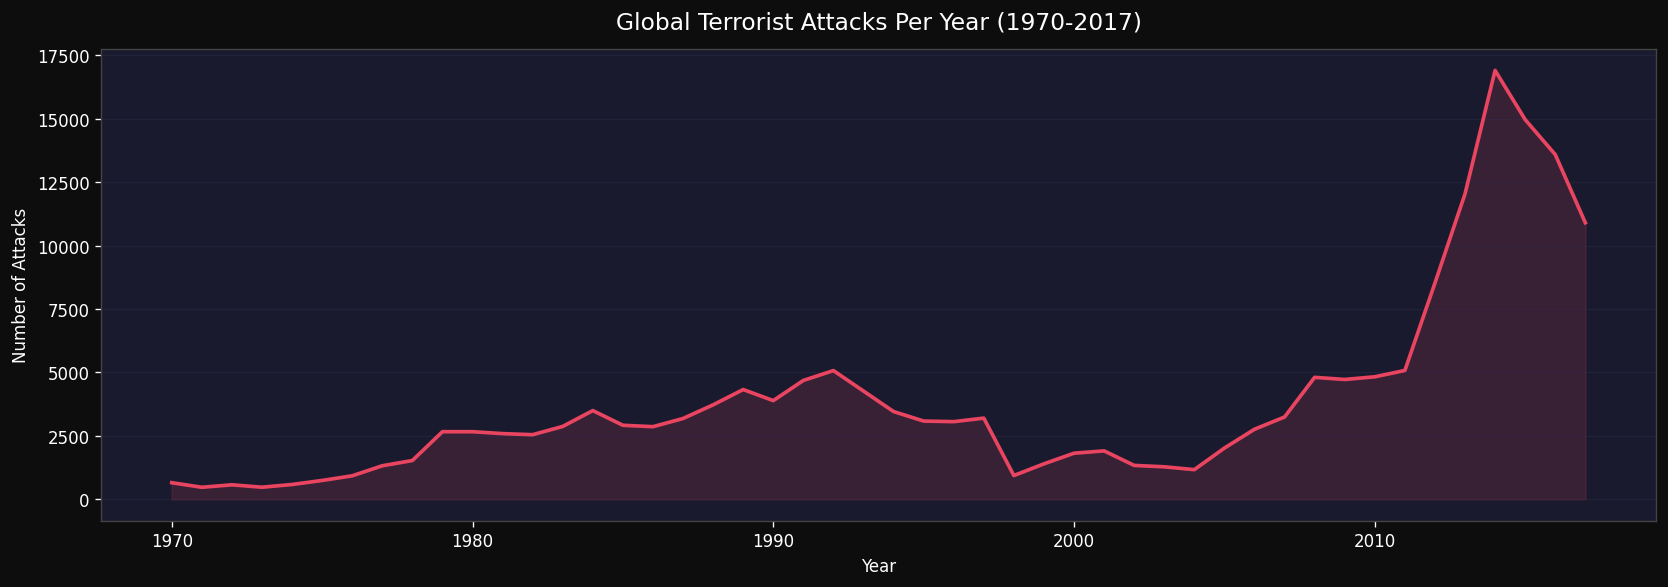

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(attacks_per_year['Year'], attacks_per_year['Attacks'], color='#e94560', linewidth=2.2)
ax.fill_between(attacks_per_year['Year'], attacks_per_year['Attacks'], alpha=0.15, color='#e94560')
ax.set_title('Global Terrorist Attacks Per Year (1970-2017)', fontsize=14, pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Attacks')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Chart 2 - Top 10 Countries

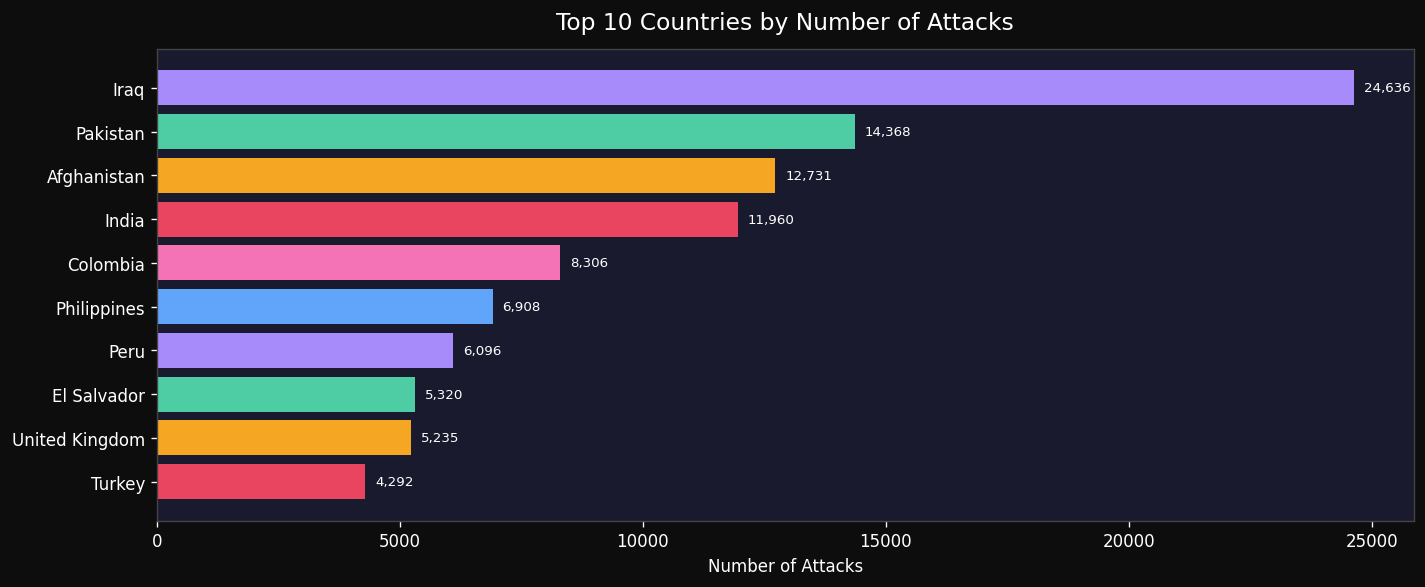

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(top_countries.index[::-1], top_countries.values[::-1], color=PALETTE * 2)
ax.set_title('Top 10 Countries by Number of Attacks', fontsize=14, pad=12)
ax.set_xlabel('Number of Attacks')
for bar in bars:
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width()):,}', va='center', fontsize=8, color='white')
plt.tight_layout()
plt.show()

## Chart 3 - Attack Types Distribution

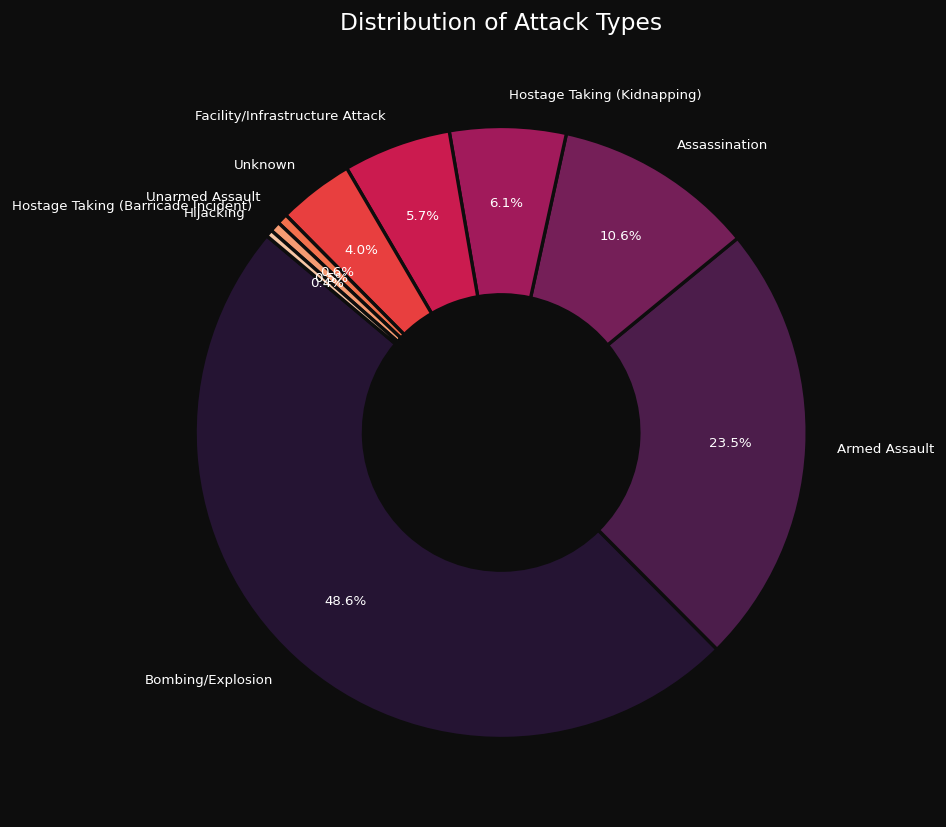

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
wedge_props = dict(width=0.55, edgecolor='#0d0d0d', linewidth=2)
ax.pie(attack_type_counts.values, labels=attack_type_counts.index,
       autopct='%1.1f%%', startangle=140,
       colors=sns.color_palette('rocket', len(attack_type_counts)),
       wedgeprops=wedge_props, pctdistance=0.75, textprops={'fontsize': 8})
ax.set_title('Distribution of Attack Types', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

## Chart 4 - Fatalities by Region

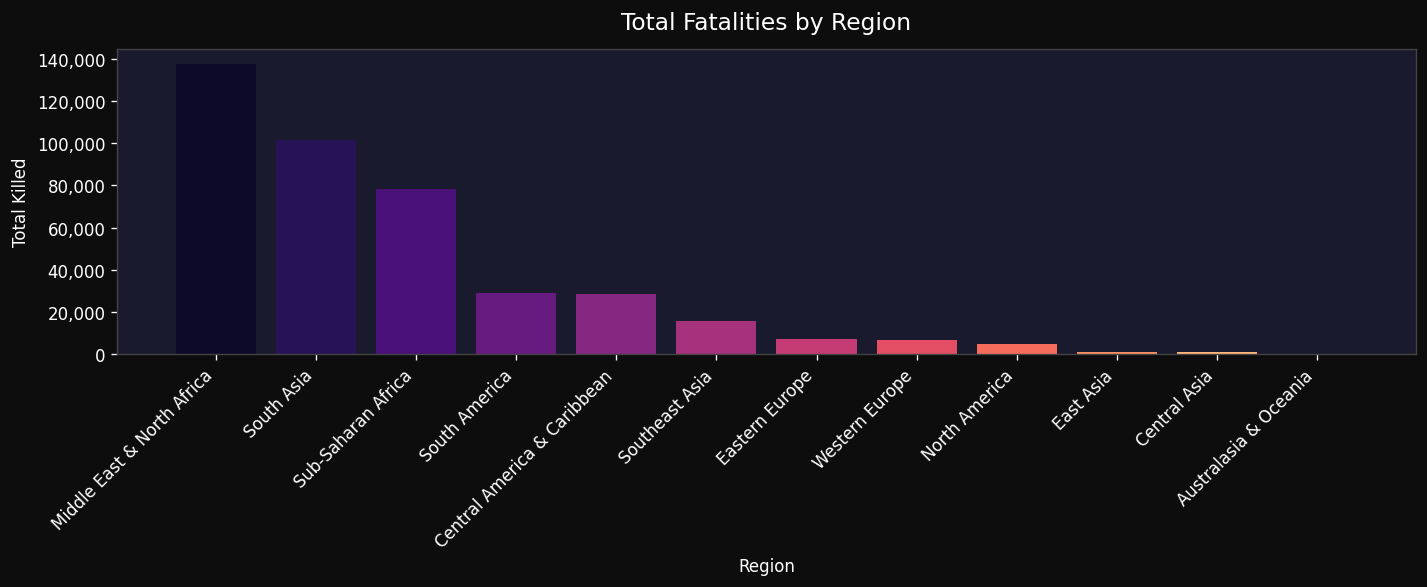

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
colors = sns.color_palette('magma', len(region_kills))
ax.bar(region_kills.index, region_kills.values, color=colors, edgecolor='none')
ax.set_title('Total Fatalities by Region', fontsize=14, pad=12)
ax.set_xlabel('Region')
ax.set_ylabel('Total Killed')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Chart 5 - Attacks by Region and Decade (Heatmap)

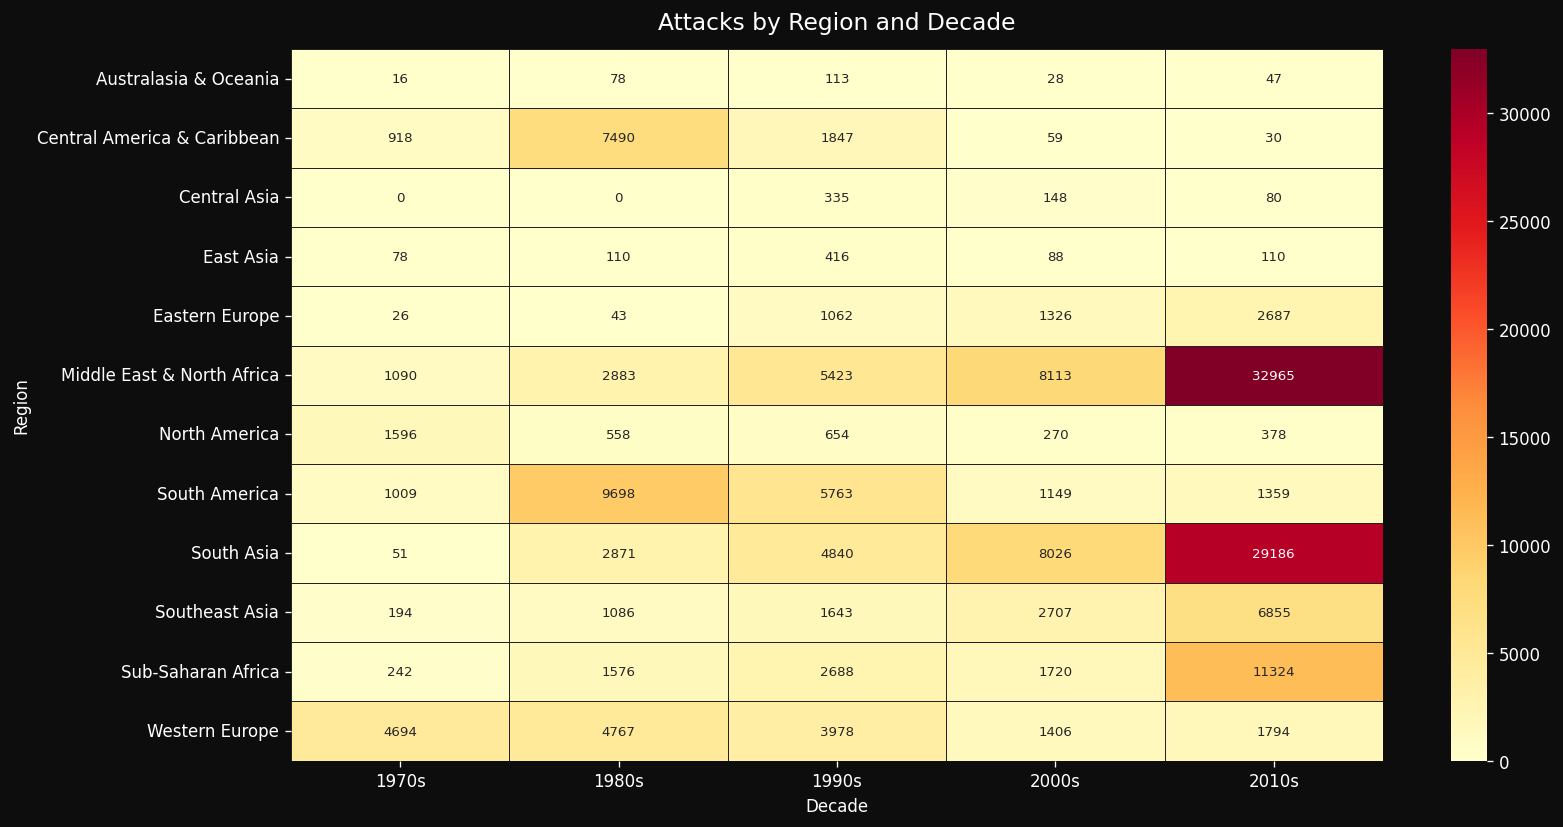

In [ ]:
region_decade = df_sub.groupby(['Region', 'Decade']).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(region_decade, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.4, linecolor='#222', ax=ax, annot_kws={'size': 8})
ax.set_title('Attacks by Region and Decade', fontsize=14, pad=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Chart 6 - Top Terrorist Groups

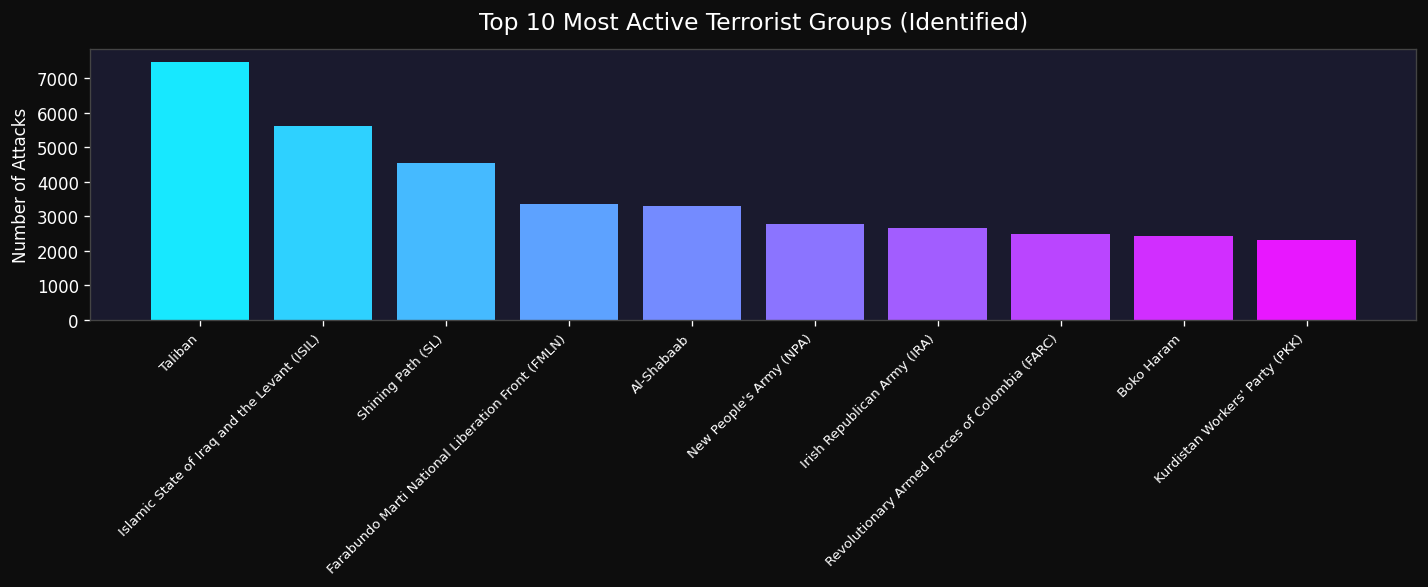

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(top_groups.index, top_groups.values, color=sns.color_palette('cool', len(top_groups)))
ax.set_title('Top 10 Most Active Terrorist Groups (Identified)', fontsize=14, pad=12)
ax.set_ylabel('Number of Attacks')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

## Chart 7 - Killed vs Wounded Per Year

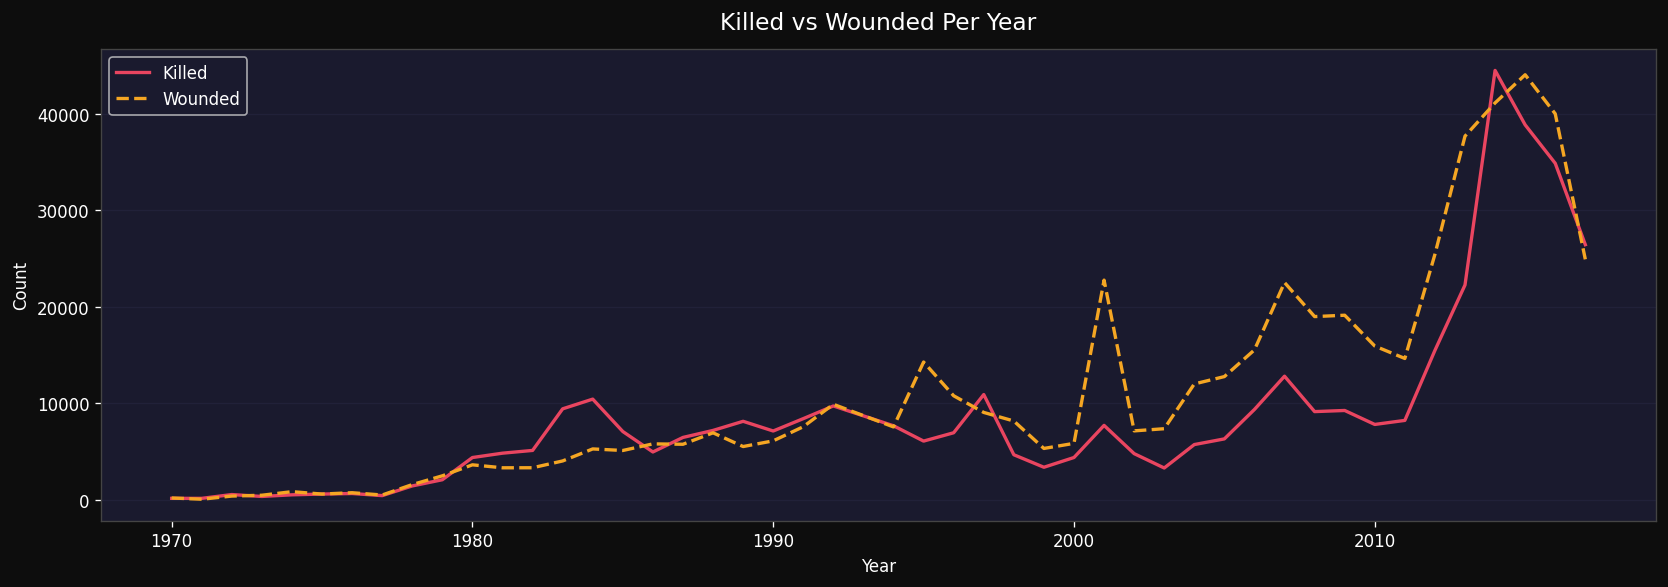

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(casualties_per_yr['Year'], casualties_per_yr['Killed'], label='Killed', color='#e94560', linewidth=2)
ax.plot(casualties_per_yr['Year'], casualties_per_yr['Wounded'], label='Wounded', color='#f5a623', linewidth=2, linestyle='--')
ax.set_title('Killed vs Wounded Per Year', fontsize=14, pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('Count')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Chart 8 - Killed Distribution by Attack Type (Boxplot)

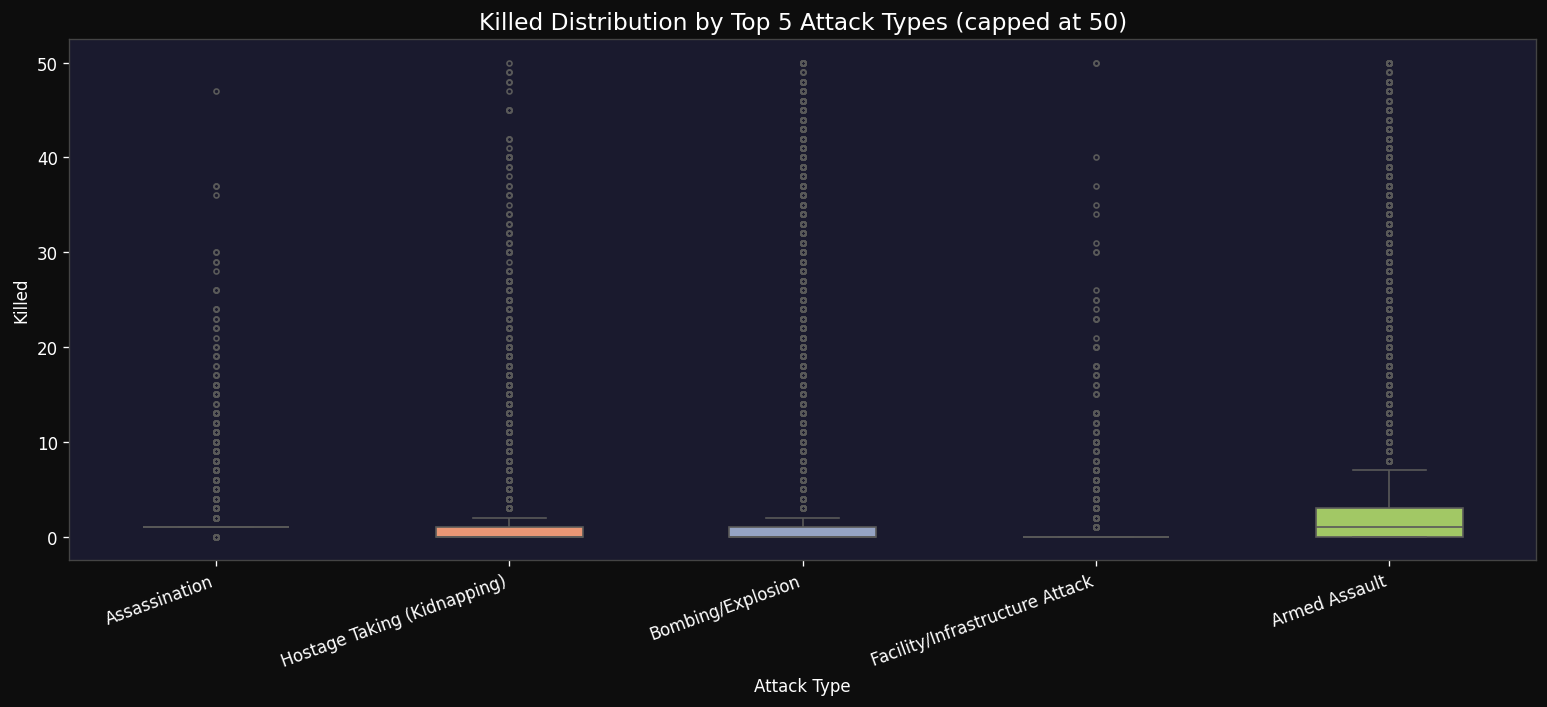

In [ ]:
top5_attack = df_sub['Attack_Type'].value_counts().head(5).index
df_box = df_sub[df_sub['Attack_Type'].isin(top5_attack) & (df_sub['Killed'] <= 50)]
fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(data=df_box, x='Attack_Type', y='Killed',
            hue='Attack_Type', palette='Set2', width=0.5, legend=False,
            flierprops=dict(marker='o', markersize=3), ax=ax)
ax.set_title('Killed Distribution by Top 5 Attack Types (capped at 50)', fontsize=14)
ax.set_xlabel('Attack Type')
ax.set_ylabel('Killed')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## Chart 9 - Weapon Types

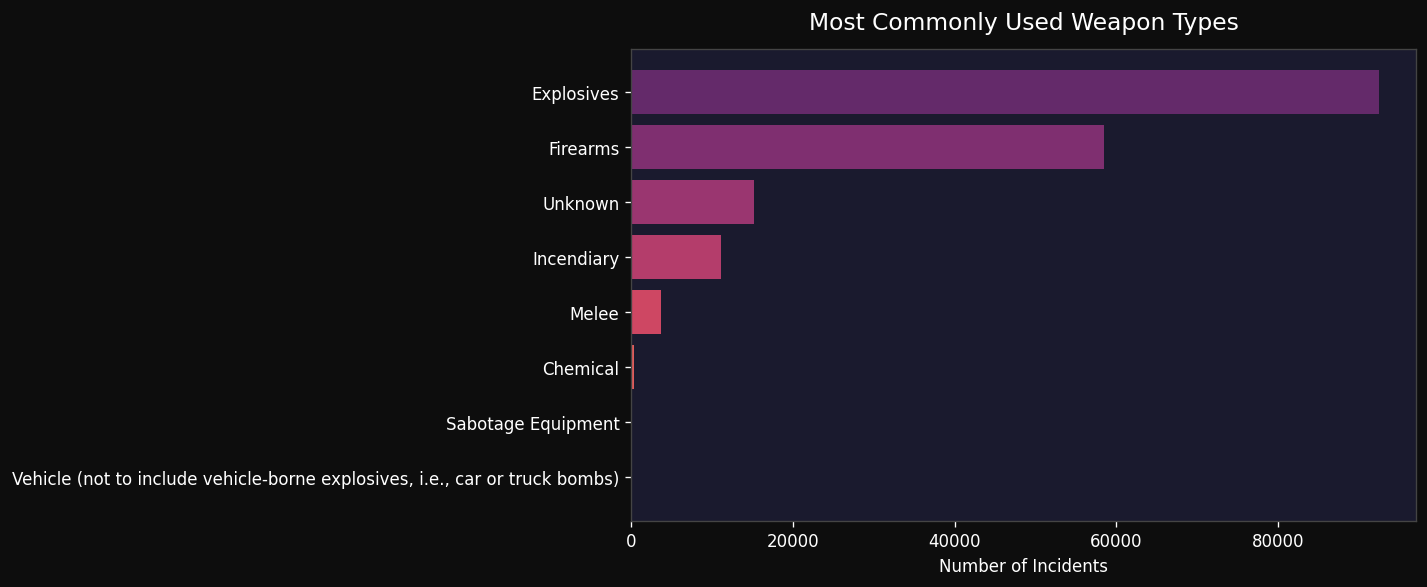

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(weapon_counts.index[::-1], weapon_counts.values[::-1],
        color=sns.color_palette('flare', len(weapon_counts)))
ax.set_title('Most Commonly Used Weapon Types', fontsize=14, pad=12)
ax.set_xlabel('Number of Incidents')
plt.tight_layout()
plt.show()

## Chart 10 - Monthly Attack Distribution

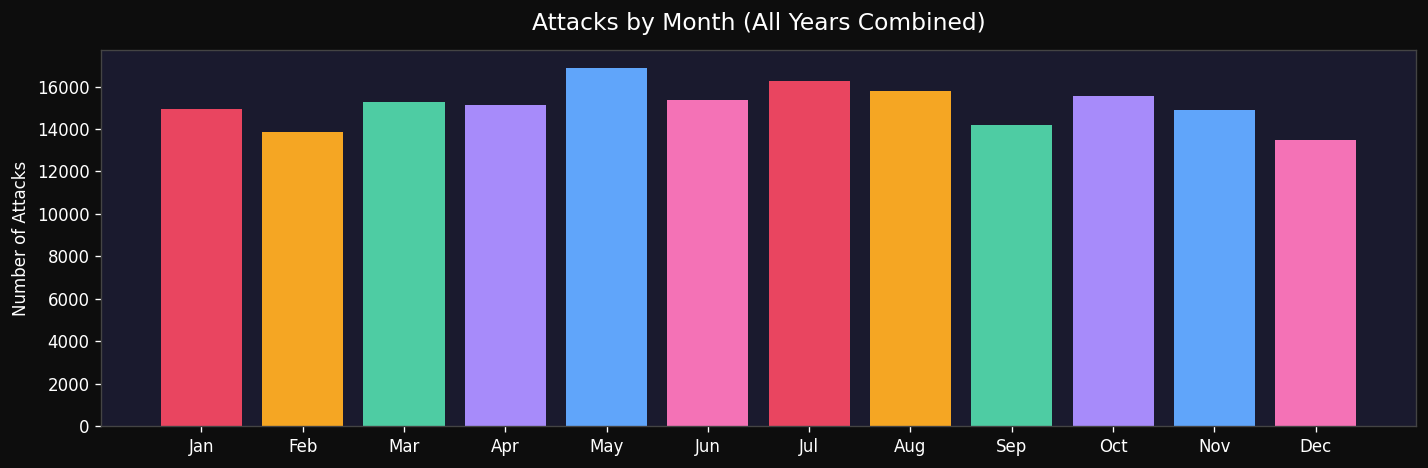

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(monthly_attacks['Month_Name'], monthly_attacks['Attacks'], color=PALETTE * 2, edgecolor='none')
ax.set_title('Attacks by Month (All Years Combined)', fontsize=14, pad=12)
ax.set_ylabel('Number of Attacks')
plt.tight_layout()
plt.show()

## Chart 11 - Killed vs Wounded Scatter

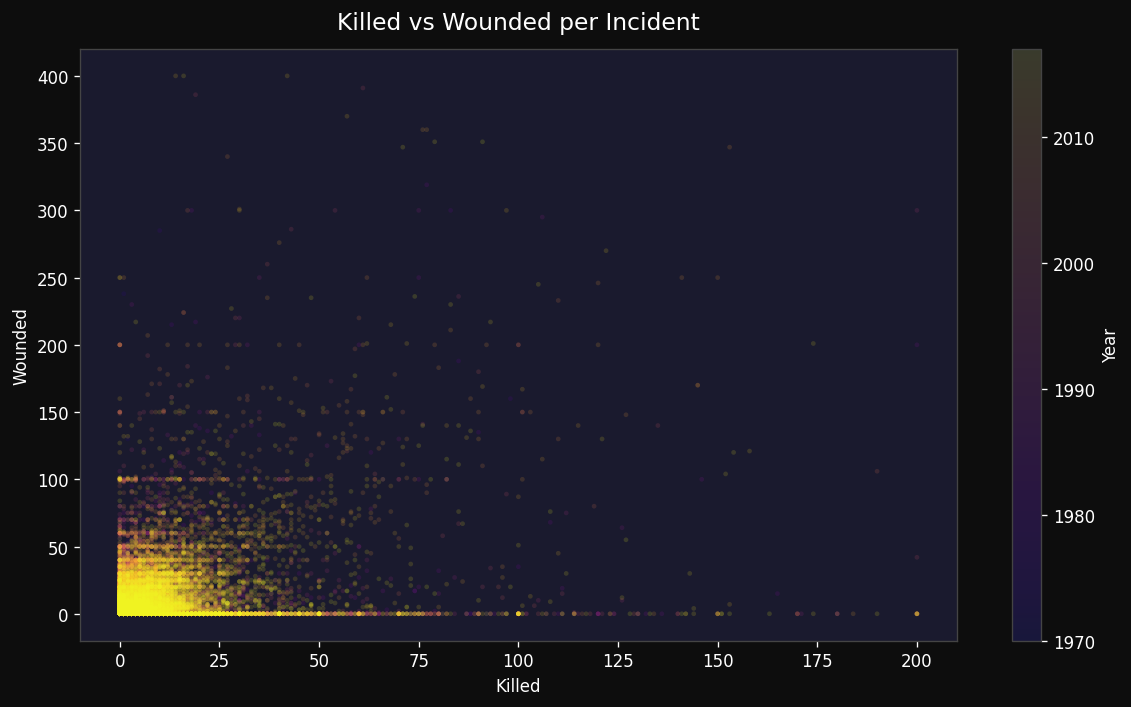

In [ ]:
df_scatter = df_sub[(df_sub['Killed'] <= 200) & (df_sub['Wounded'] <= 400)]
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(df_scatter['Killed'], df_scatter['Wounded'],
                alpha=0.15, s=8, c=df_scatter['Year'],
                cmap='plasma', edgecolors='none')
plt.colorbar(sc, ax=ax, label='Year')
ax.set_title('Killed vs Wounded per Incident', fontsize=14, pad=12)
ax.set_xlabel('Killed')
ax.set_ylabel('Wounded')
plt.tight_layout()
plt.show()

## Chart 12 - Success and Suicide Attacks

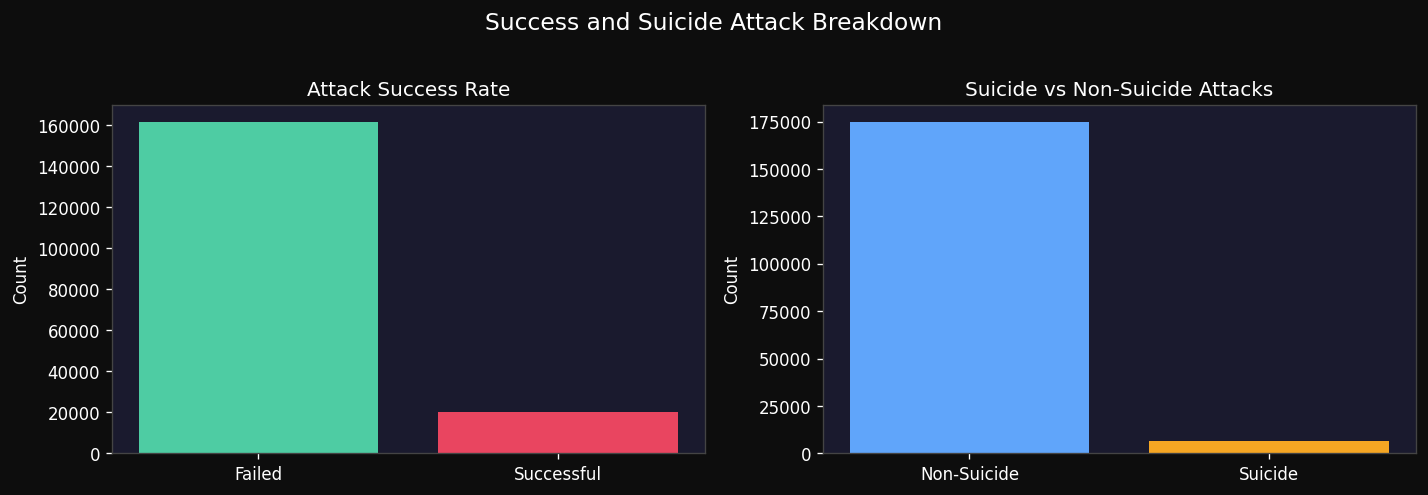

In [ ]:
success_counts = df_sub['Success'].value_counts()
suicide_counts = df_sub['Suicide'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['Failed', 'Successful'], success_counts.values, color=['#4ecca3', '#e94560'])
axes[0].set_title('Attack Success Rate', fontsize=12)
axes[0].set_ylabel('Count')
axes[1].bar(['Non-Suicide', 'Suicide'], suicide_counts.values, color=['#60a5fa', '#f5a623'])
axes[1].set_title('Suicide vs Non-Suicide Attacks', fontsize=12)
axes[1].set_ylabel('Count')
plt.suptitle('Success and Suicide Attack Breakdown', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Chart 13 - Correlation Heatmap

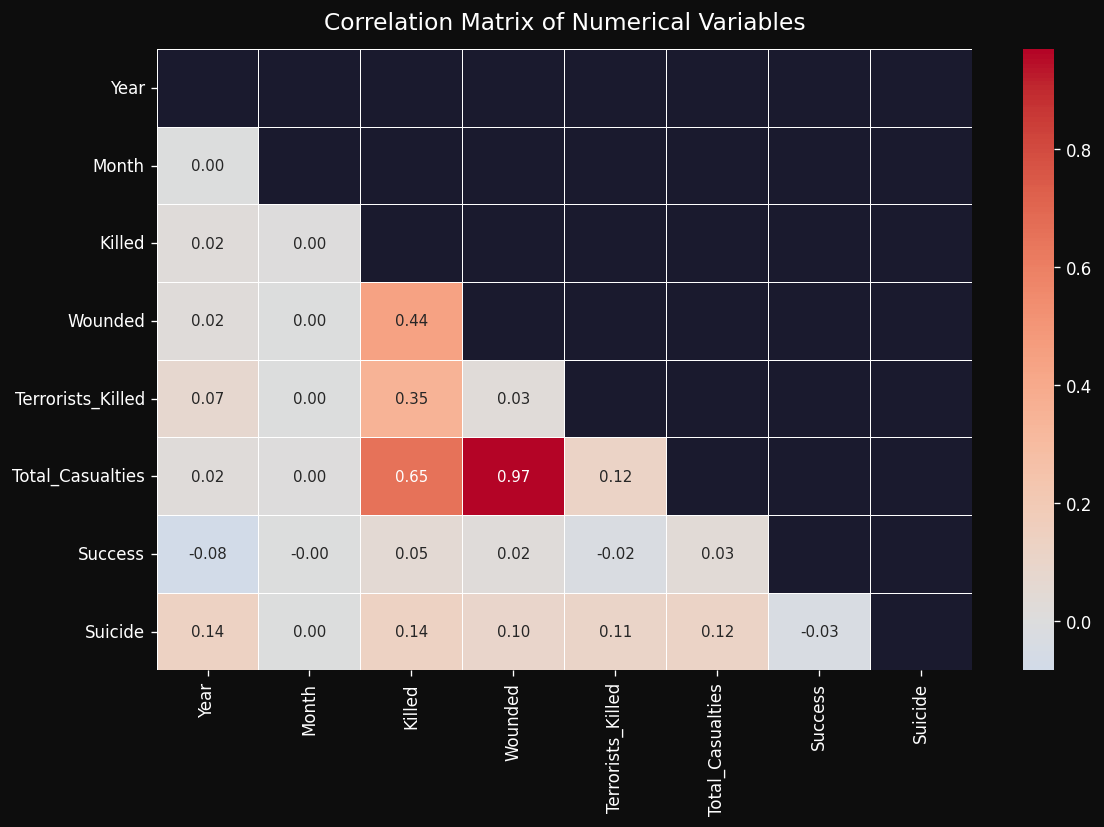

In [ ]:
num_cols = ['Year', 'Month', 'Killed', 'Wounded', 'Terrorists_Killed', 'Total_Casualties', 'Success', 'Suicide']
corr = df_sub[num_cols].corr()
fig, ax = plt.subplots(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Correlation Matrix of Numerical Variables', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

## Chart 14 - Attacks by Decade

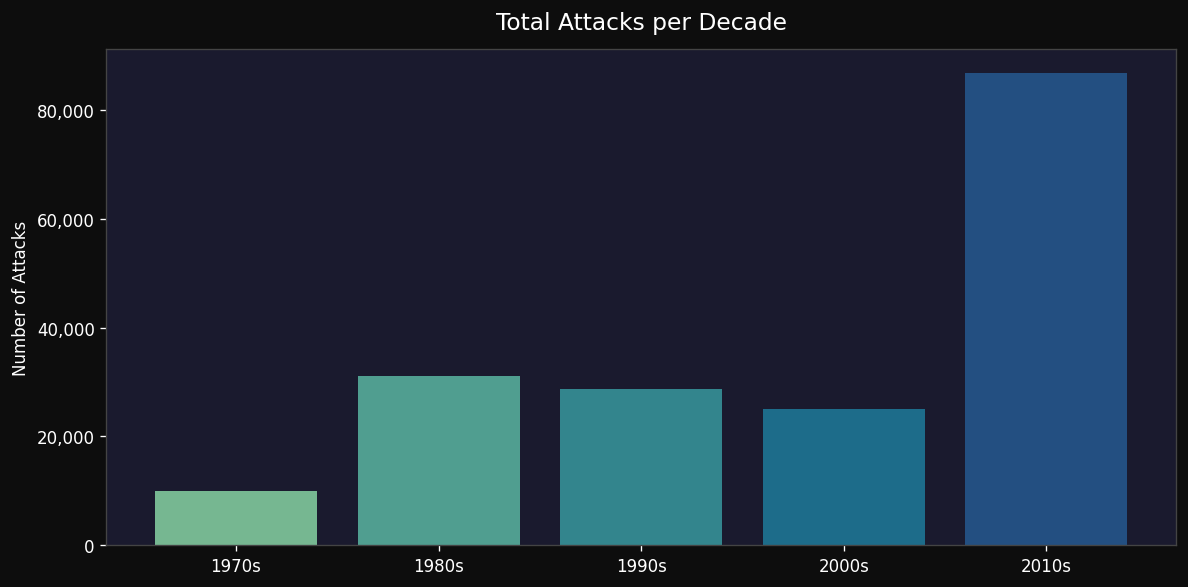

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(decade_attacks['Decade'], decade_attacks['Attacks'],
       color=sns.color_palette('crest', len(decade_attacks)))
ax.set_title('Total Attacks per Decade', fontsize=14, pad=12)
ax.set_ylabel('Number of Attacks')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## Chart 15 - Pairplot

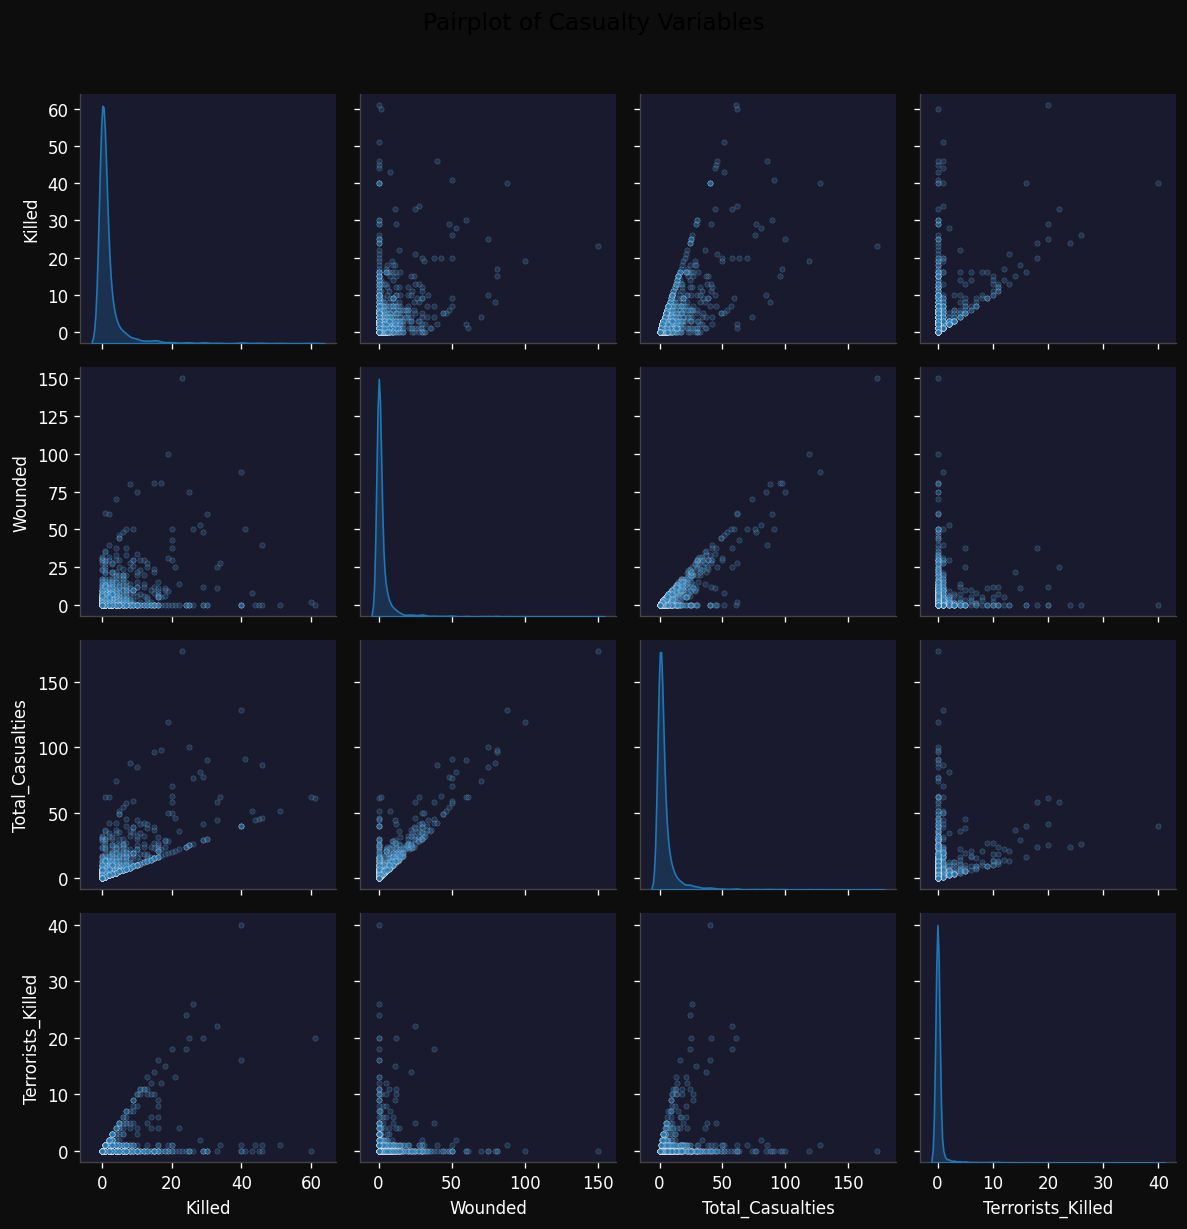

In [ ]:
pair_df = df_sub[['Killed', 'Wounded', 'Total_Casualties', 'Terrorists_Killed']].dropna().sample(3000, random_state=42)
pair_df = pair_df[(pair_df['Killed'] <= 100) & (pair_df['Wounded'] <= 200)]
pair_grid = sns.pairplot(pair_df, diag_kind='kde', plot_kws={'alpha': 0.3, 's': 10}, palette='husl')
pair_grid.fig.suptitle('Pairplot of Casualty Variables', y=1.02, fontsize=14, color='black')
plt.tight_layout()
plt.show()

## Solution to Business Objective

In [ ]:
print("1. Iraq, Pakistan, Afghanistan, India, and Colombia are the most attack-prone nations.")
print("   Security agencies should prioritize resource allocation in these regions.")
print()
print("2. Bombings account for around 50 percent of all attacks.")
print("   Explosive detection technology and public awareness must be enhanced.")
print()
print("3. Taliban, ISIS/ISIL, and affiliated groups drive most identified attacks.")
print("   Intelligence efforts must focus on monitoring these networks.")
print()
print("4. Attacks surged post-2011 and the 2010s is the deadliest decade on record.")
print("   Policymakers need updated counter-terrorism strategies.")
print()
print("5. High wound-to-kill ratio suggests medical response systems in conflict zones")
print("   can be strengthened to reduce overall mortality.")

1. Iraq, Pakistan, Afghanistan, India, and Colombia are the most attack-prone nations.
   Security agencies should prioritize resource allocation in these regions.

2. Bombings account for around 50 percent of all attacks.
   Explosive detection technology and public awareness must be enhanced.

3. Taliban, ISIS/ISIL, and affiliated groups drive most identified attacks.
   Intelligence efforts must focus on monitoring these networks.

4. Attacks surged post-2011 and the 2010s is the deadliest decade on record.
   Policymakers need updated counter-terrorism strategies.

5. High wound-to-kill ratio suggests medical response systems in conflict zones
   can be strengthened to reduce overall mortality.


## Conclusion

In [ ]:
print("This EDA of the UNGTA Global Terrorism Dataset from 1970 to 2017 revealed critical patterns.")
print("Global terrorism intensified dramatically after 2010.")
print("The Middle East and South Asia are the most affected regions.")
print("Bombings and explosives are the primary mode of attack.")
print("Taliban and ISIS/ISIL are the most prolific identified groups.")
print("Casualty numbers are right-skewed as most attacks affect small numbers but mass-casualty events drive the averages up.")
print("Data-driven intelligence can significantly improve counter-terrorism policy, resource planning, and public safety.")

This EDA of the UNGTA Global Terrorism Dataset from 1970 to 2017 revealed critical patterns.
Global terrorism intensified dramatically after 2010.
The Middle East and South Asia are the most affected regions.
Bombings and explosives are the primary mode of attack.
Taliban and ISIS/ISIL are the most prolific identified groups.
Casualty numbers are right-skewed as most attacks affect small numbers but mass-casualty events drive the averages up.
Data-driven intelligence can significantly improve counter-terrorism policy, resource planning, and public safety.
